## This notebook is used to explore the provided data, understand how these ETFs basically work, and fit some univariate GARCH models for benchmarking.

In [1]:
#!/usr/bin/env python
# coding: utf-8

# =========================
# IMPORTS
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import unicodedata
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

In [3]:
# =========================
# SETUP
# =========================

os.makedirs("output_folder", exist_ok=True)

etf_path = r'C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Projects\DCC Garch Rompolis\data\ETF_sector_prices.xlsx'
market_path = r'C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Projects\DCC Garch Rompolis\data\ETF_SP500_prices.xlsx'

In [5]:
# =========================
# HELPERS
# =========================

def fix_tickers(cols):
    """Fix Greek → Latin characters safely"""
    mapping = {'Β': 'B'}
    out = []
    for c in cols:
        for k, v in mapping.items():
            c = c.replace(k, v)
        out.append(c)
    return out

def validate_columns(df, expected_cols):
    missing = set(expected_cols) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

In [7]:
# =========================
# LOAD DATA
# =========================

etf_data = pd.read_excel(etf_path)
market_data = pd.read_excel(market_path)

# =========================
# SET DATE INDEX (CRITICAL)
# =========================

etf_data['dates'] = pd.to_datetime(etf_data['dates'])
etf_data = etf_data.set_index('dates')

market_data['dates'] = pd.to_datetime(market_data['dates'])
market_data = market_data.set_index('dates')

# =========================
# EXTRACT TOTAL RETURNS
# =========================

tr_cols = [c for c in etf_data.columns if "TOT RETURN IND" in c]
tr = etf_data[tr_cols].copy()

# =========================
# FIX COLUMN NAMES (ORDER MATTERS)
# =========================

tr.columns = fix_tickers(tr.columns)
tr.columns = [c.split(" ")[0] for c in tr.columns]

In [9]:
# =========================
# MARKET DATA
# =========================

market_tr = market_data[['STATE STREET SPDR S&P 500 ETF TRUST - TOT RETURN IND']].copy()
market_tr.columns = ['SPY']

# =========================
# MERGE (SAFE)
# =========================

tr = tr.join(market_tr, how='inner')

# =========================
# VALIDATE STRUCTURE
# =========================

cols = ['SPY','XLB','XLE','XLF','XLI','XLK','XLP','XLU','XLV','XLY']
validate_columns(tr, cols)

tr = tr[cols]

# =========================
# RETURNS (ONLY ONCE)
# =========================

returns = np.log(tr / tr.shift(1)).dropna()

returns.to_csv("output_folder/sector_etf_log_returns.csv", index_label="date")

      count      mean       std       min       25%       50%       75%  \
SPY  7099.0  0.000310  0.011931 -0.115884 -0.004388  0.000408  0.005834   
XLB  7099.0  0.000306  0.014627 -0.132548 -0.006706  0.000201  0.007870   
XLE  7099.0  0.000322  0.017790 -0.224914 -0.007940  0.000120  0.009298   
XLF  7099.0  0.000212  0.017562 -0.182322 -0.006402  0.000000  0.007362   
XLI  7099.0  0.000349  0.013066 -0.120419 -0.005404  0.000462  0.006701   
XLK  7099.0  0.000349  0.015999 -0.148686 -0.006220  0.000611  0.007773   
XLP  7099.0  0.000255  0.009426 -0.098675 -0.004200  0.000170  0.005049   
XLU  7099.0  0.000293  0.011912 -0.120574 -0.005225  0.000417  0.006449   
XLV  7099.0  0.000312  0.011047 -0.103816 -0.004831  0.000216  0.005965   
XLY  7099.0  0.000352  0.014051 -0.135456 -0.005863  0.000391  0.007298   

          max      skew   kurtosis  
SPY  0.135588 -0.196532  11.766659  
XLB  0.131541 -0.195487   6.874515  
XLE  0.152521 -0.641503  12.723023  
XLF  0.151800 -0.140944  1

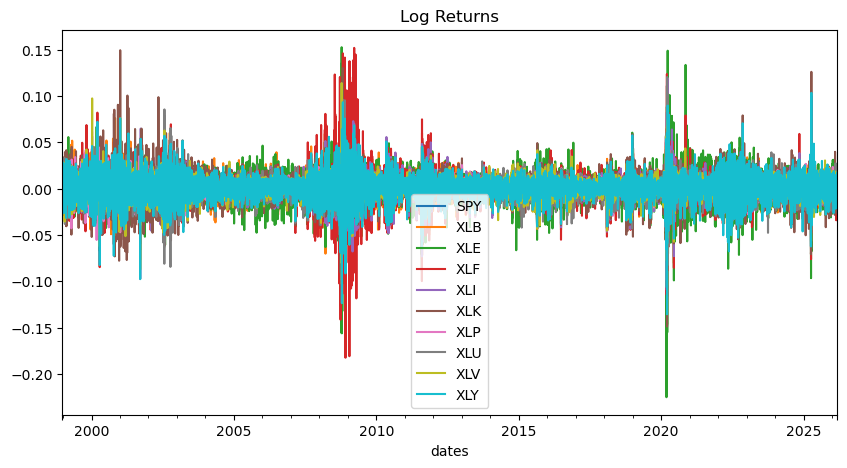

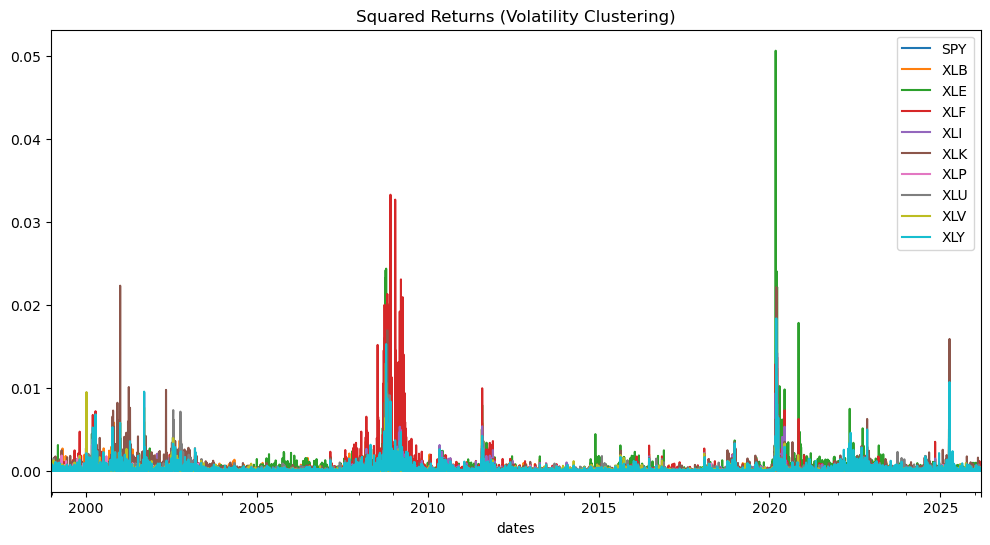

In [11]:
# =========================
# EDA
# =========================

desc = returns.describe().T
desc['skew'] = returns.skew()
desc['kurtosis'] = returns.kurtosis()
print(desc)

# Plot returns
returns.plot(figsize=(10,5))
plt.title("Log Returns")
plt.show()

# Vol clustering
(returns**2).plot(figsize=(12,6))
plt.title("Squared Returns (Volatility Clustering)")
plt.show()


ADF STATIONARITY TEST
SPY: p-value = 0.00000
XLB: p-value = 0.00000
XLE: p-value = 0.00000
XLF: p-value = 0.00000
XLI: p-value = 0.00000
XLK: p-value = 0.00000
XLP: p-value = 0.00000
XLU: p-value = 0.00000
XLV: p-value = 0.00000
XLY: p-value = 0.00000

LJUNG-BOX (returns)
SPY 
       lb_stat     lb_pvalue
10  75.539595  3.735420e-12 

XLB 
      lb_stat  lb_pvalue
10  19.02396   0.039959 

XLE 
       lb_stat  lb_pvalue
10  27.398997   0.002251 

XLF 
        lb_stat     lb_pvalue
10  123.213866  1.125657e-21 

XLI 
       lb_stat  lb_pvalue
10  39.803137   0.000018 

XLK 
      lb_stat     lb_pvalue
10  66.68612  1.926325e-10 

XLP 
      lb_stat     lb_pvalue
10  81.21175  2.904370e-13 

XLU 
       lb_stat     lb_pvalue
10  66.020749  2.584334e-10 

XLV 
      lb_stat     lb_pvalue
10  52.60417  8.818195e-08 

XLY 
       lb_stat  lb_pvalue
10  41.726435   0.000008 


LJUNG-BOX (squared returns)
SPY 
         lb_stat  lb_pvalue
10  5557.220128        0.0 

XLB 
         lb_stat  lb

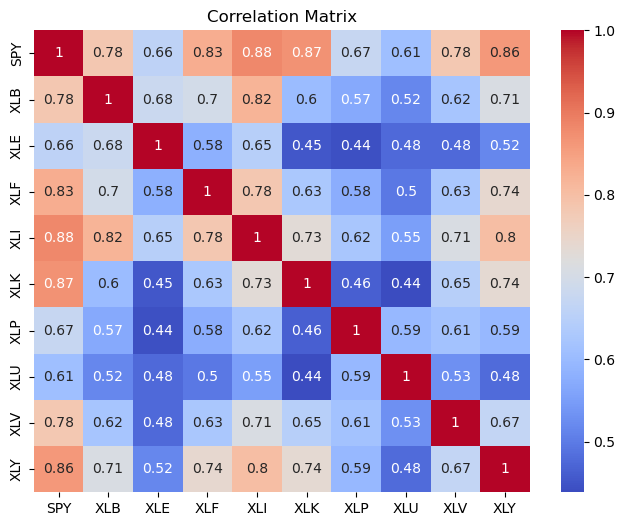

SPY 
       lb_stat  lb_pvalue
10  10.481857   0.399282
XLB 
       lb_stat  lb_pvalue
10  12.370915   0.260999
XLE 
       lb_stat  lb_pvalue
10  16.610622   0.083436
XLF 
      lb_stat  lb_pvalue
10  14.80504   0.139333
XLI 
     lb_stat  lb_pvalue
10  6.27094    0.79201
XLK 
       lb_stat  lb_pvalue
10  10.454999   0.401521
XLP 
      lb_stat  lb_pvalue
10  8.005977   0.628253
XLU 
       lb_stat  lb_pvalue
10  24.510549   0.006355
XLV 
      lb_stat  lb_pvalue
10  5.292818   0.870779
XLY 
      lb_stat  lb_pvalue
10  5.059552   0.887165


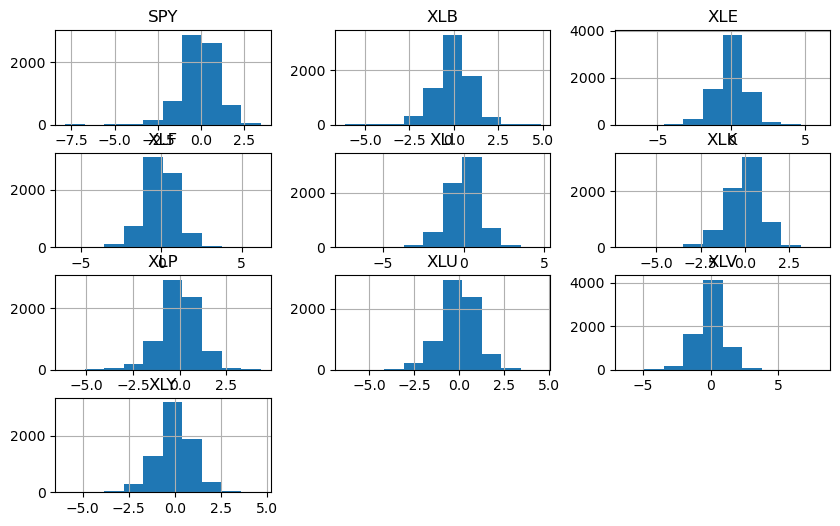

          omega     alpha      beta     gamma        nu  alpha+beta
asset                                                              
SPY    0.016493  0.000000  0.884345  0.206385  5.877047    0.884345
XLB    0.022363  0.022642  0.916190  0.099170  8.115391    0.938832
XLE    0.024719  0.032069  0.926353  0.063280  8.845347    0.958422
XLF    0.024585  0.026057  0.894638  0.141954  6.116206    0.920694
XLI    0.017758  0.000640  0.920760  0.129435  6.997115    0.921400
XLK    0.016780  0.017745  0.908481  0.133692  6.577840    0.926226
XLP    0.013386  0.028137  0.902877  0.102499  7.070296    0.931014
XLU    0.019871  0.038153  0.910109  0.065767  7.284204    0.948262
XLV    0.021429  0.019898  0.900470  0.118151  6.518920    0.920368
XLY    0.015035  0.021988  0.911248  0.116827  7.640155    0.933236


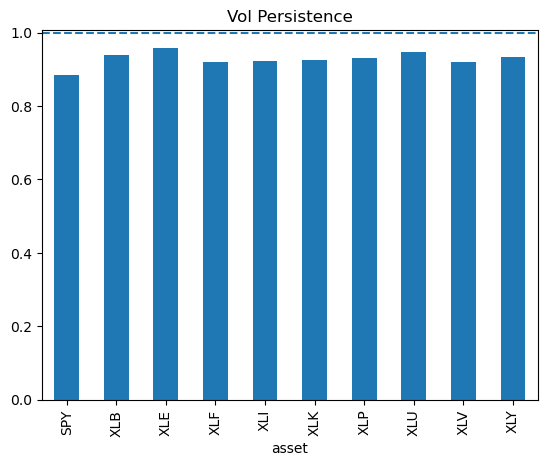

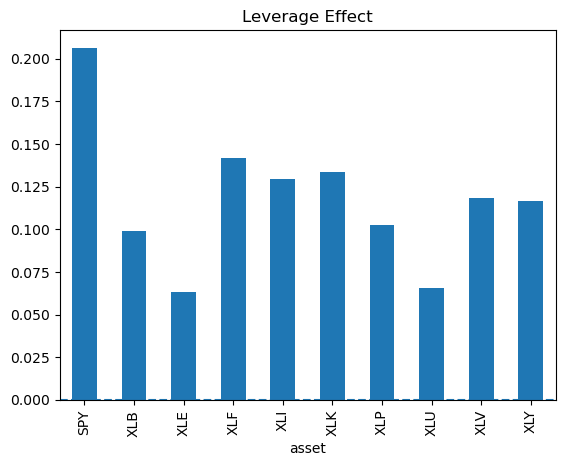

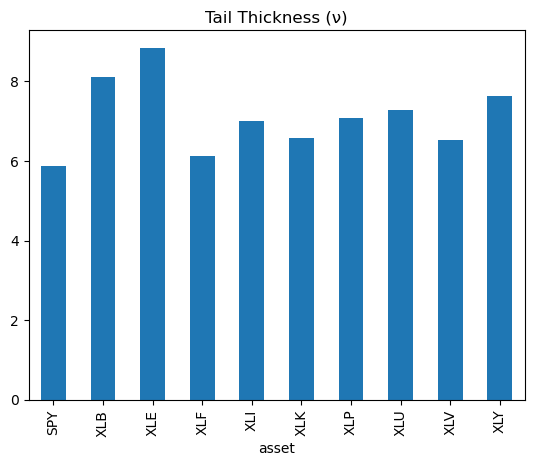

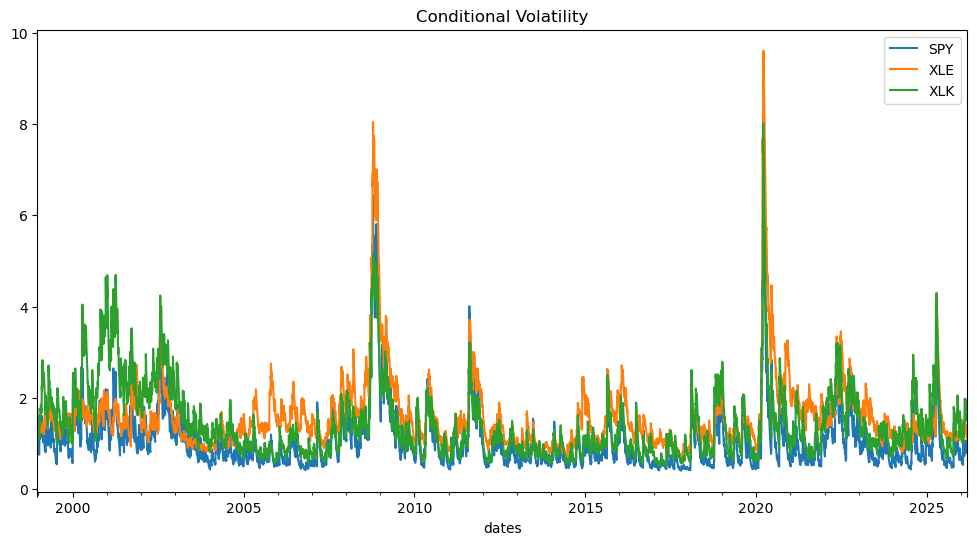

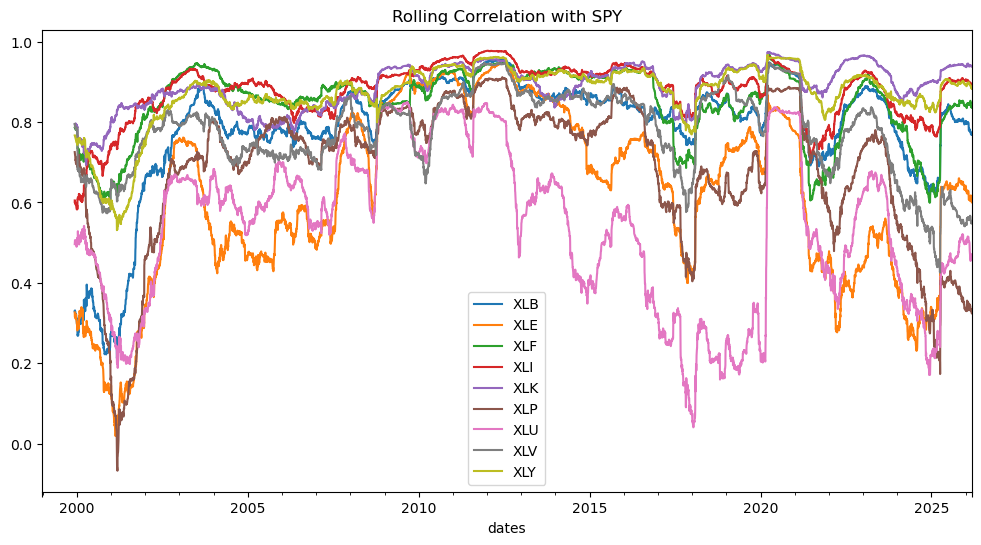

In [13]:
# =========================
# STATISTICAL TESTS
# =========================

print("\nADF STATIONARITY TEST")
for col in returns.columns:
    stat, pval, _, _, _, _ = adfuller(returns[col])
    print(f"{col}: p-value = {pval:.5f}")

print("\nLJUNG-BOX (returns)")
for col in returns.columns:
    test = acorr_ljungbox(returns[col], lags=[10], return_df=True)
    print(col, "\n", test, "\n")

print("\nLJUNG-BOX (squared returns)")
for col in returns.columns:
    test = acorr_ljungbox(returns[col]**2, lags=[10], return_df=True)
    print(col, "\n", test, "\n")

print("\nARCH TEST")
for col in returns.columns:
    stat, pval, _, _ = het_arch(returns[col])
    print(col, "ARCH p-value:", pval)

# =========================
# CORRELATION
# =========================

corr = returns.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# =========================
# GJR-GARCH FIT
# =========================

garch_results = {}
std_resids = {}

for col in returns.columns:
    model = arch_model(
        returns[col] * 100,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="t"
    )
    res = model.fit(disp="off")
    garch_results[col] = res
    std_resids[col] = res.std_resid

std_resids = pd.DataFrame(std_resids, index=returns.index)

# =========================
# RESIDUAL DIAGNOSTICS
# =========================

for col in std_resids.columns:
    test = acorr_ljungbox(std_resids[col]**2, lags=[10], return_df=True)
    print(col, "\n", test)

std_resids.hist(figsize=(10,6))
plt.show()

# =========================
# PARAMETER EXTRACTION
# =========================

param_table = []

for asset, res in garch_results.items():
    p = res.params
    param_table.append({
        "asset": asset,
        "omega": p['omega'],
        "alpha": p['alpha[1]'],
        "beta": p['beta[1]'],
        "gamma": p['gamma[1]'],
        "nu": p['nu'],
        "alpha+beta": p['alpha[1]'] + p['beta[1]']
    })

param_df = pd.DataFrame(param_table).set_index("asset")
print(param_df)

# =========================
# VISUALIZATION
# =========================

param_df["alpha+beta"].plot(kind="bar")
plt.axhline(1, linestyle="--")
plt.title("Vol Persistence")
plt.show()

param_df["gamma"].plot(kind="bar")
plt.axhline(0, linestyle="--")
plt.title("Leverage Effect")
plt.show()

param_df["nu"].plot(kind="bar")
plt.title("Tail Thickness (ν)")
plt.show()

# Conditional vol
plt.figure(figsize=(12,6))
for asset in ["SPY","XLE","XLK"]:
    garch_results[asset].conditional_volatility.plot(label=asset)
plt.legend()
plt.title("Conditional Volatility")
plt.show()

# =========================
# ROLLING CORRELATION
# =========================

window = 252
rolling_corr_spy = pd.DataFrame(index=returns.index)

for col in returns.columns:
    if col != "SPY":
        rolling_corr_spy[col] = returns[col].rolling(window).corr(returns["SPY"])

rolling_corr_spy.plot(figsize=(12,6))
plt.title("Rolling Correlation with SPY")
plt.show()

In [17]:
# =========================
# DCC INPUTS
# =========================

Z_df = std_resids.copy()
Z = Z_df.values

Q_bar = np.cov(Z.T)

sigmas = pd.DataFrame({
    col: garch_results[col].conditional_volatility
    for col in returns.columns
}, index=returns.index)

dcc_inputs = {
    "Z": Z_df,
    "Q_bar": Q_bar,
    "sigmas": sigmas,
    "returns": returns,
    "assets": returns.columns.tolist(),
    "dates": returns.index
}

In [19]:
# =========================
# SAVE (EXPLICIT PATH)
# =========================

output_path = r'C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Projects\DCC Garch Rompolis\data'

# Ensure directory exists (safe even if it already does)
os.makedirs(output_path, exist_ok=True)

pkl_path = os.path.join(output_path, "dcc_inputs.pkl")

with open(pkl_path, "wb") as f:
    pickle.dump(dcc_inputs, f)

print(f"\nDCC inputs saved successfully at:\n{pkl_path}")


DCC inputs saved successfully at:
C:\Users\pcarg\OneDrive\Υπολογιστής\MFE UCLA\Projects\DCC Garch Rompolis\data\dcc_inputs.pkl
